In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Define a function to generate synthetic data with categorical features
def generate_categorical_data(n_samples=1000):
    np.random.seed(42)  # Set a random seed for reproducibility
    # Create a matrix X with 'n_samples' rows and 3 columns, values ranging from 0 to 4 (5 categories)
    X = np.random.randint(0, 5, size=(n_samples, 3))
    # Create a target variable 'y' based on a formula that combines the features in 'X' with some randomness
    y = (X[:, 0] + X[:, 1] * 2 + X[:, 2] * 3 + np.random.randint(0, 3, n_samples)) % 3
    return X, y  # Return the features matrix 'X' and the target array 'y'

# Generate the data using the defined function
X, y = generate_categorical_data()
# Output the features matrix 'X'
X

array([[3, 4, 2],
       [4, 4, 1],
       [2, 2, 2],
       ...,
       [4, 0, 0],
       [0, 3, 4],
       [2, 1, 3]])

In [33]:
np.unique(y)

array([0, 1, 2])

### Synthetic Categorical Data Generation

This details a function, `generate_categorical_data`, designed to create synthetic datasets with categorical features, suitable for testing classification models.

#### Key Components:

- **`np.random.seed()`**: Ensures that the random numbers generated are reproducible, providing consistency in results across different runs.

- **`np.random.randint()`**: Generates random integers. It is used here to fill the feature matrix `X` with integers within a specified range, simulating categorical data.

- **`generate_categorical_data` Function**:
  - **Purpose**: Creates a dataset with predefined complexity to simulate real-world data scenarios where the outcome depends on multiple categorical features.
  - **Outputs**: Returns two arrays, `X` (features) and `y` (target), where `X` contains categorical features and `y` is derived from a formula that introduces non-linearity and dependency among features, making it ideal for evaluating the performance of classification algorithms.

interactive(children=(FloatSlider(value=1.0, description='Laplace Smoothing Alpha', max=10.0, min=0.0001, step…

              precision    recall  f1-score   support

           0       0.37      0.38      0.37       104
           1       0.25      0.31      0.28        83
           2       0.39      0.31      0.34       113

    accuracy                           0.33       300
   macro avg       0.34      0.33      0.33       300
weighted avg       0.34      0.33      0.34       300

Accuracy: 0.333
Precision: 0.344
Recall: 0.333
F1 Score: 0.336


<Figure size 700x700 with 0 Axes>

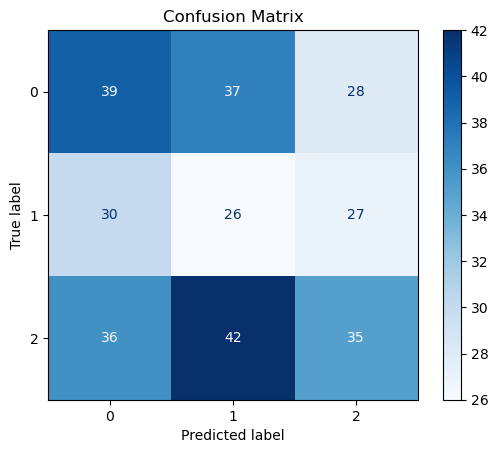

              precision    recall  f1-score   support

           0       0.37      0.38      0.37       104
           1       0.25      0.31      0.28        83
           2       0.39      0.31      0.34       113

    accuracy                           0.33       300
   macro avg       0.34      0.33      0.33       300
weighted avg       0.34      0.33      0.34       300

Accuracy: 0.333
Precision: 0.344
Recall: 0.333
F1 Score: 0.336


<Figure size 700x700 with 0 Axes>

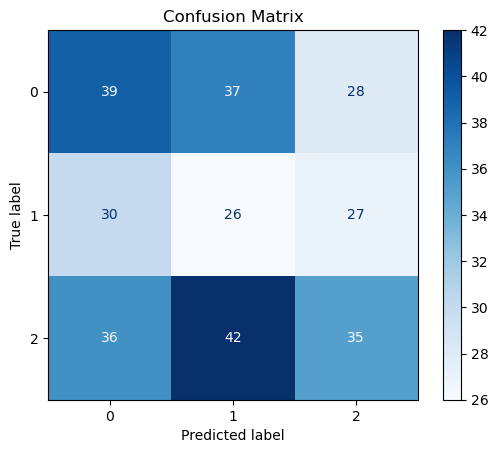

              precision    recall  f1-score   support

           0       0.37      0.38      0.37       104
           1       0.24      0.31      0.27        83
           2       0.40      0.31      0.35       113

    accuracy                           0.33       300
   macro avg       0.34      0.33      0.33       300
weighted avg       0.35      0.33      0.34       300

Accuracy: 0.333
Precision: 0.346
Recall: 0.333
F1 Score: 0.336


<Figure size 700x700 with 0 Axes>

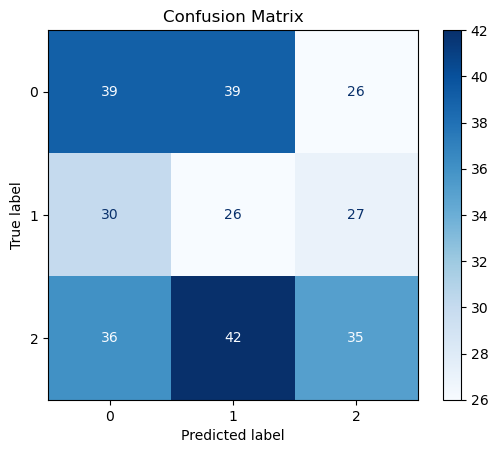

In [36]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definition of the interactive function to train and display classifier results
def train_and_display(alpha=1.0):
    # Initializing and training the Categorical Naive Bayes classifier with a specific alpha
    model = CategoricalNB(alpha=alpha)
    model.fit(X_train, y_train)
    
    # Using the trained model to predict the test dataset
    y_pred = model.predict(X_test)
    
    # Printing the classification report including metrics such as precision, recall, and F1-score
    print(classification_report(y_test, y_pred, target_names=np.unique(y).astype(str)))
    
    # Calculating additional classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Printing calculated metrics
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    
    # Computing and displaying the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure(figsize=(7, 7))
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

# Creating an interactive widget with a slider to adjust the alpha parameter
interact(train_and_display, alpha=FloatSlider(min=0.0001, max=10, step=0.001, value=1, description='Laplace Smoothing Alpha'))

train_and_display(alpha=1.0)
train_and_display(alpha=0.5)
train_and_display(alpha=2.0)


### Exploration of Categorical Naive Bayes Classifier

This Python script provides a hands-on demonstration of how the Laplace smoothing parameter (`alpha`) influences the performance of a Categorical Naive Bayes classifier, using classification metrics and a confusion matrix for visualization.

#### Detailed Explanation of the Code:
- **Naive Bayes Classifier Setup**:
  - `CategoricalNB()`: A Naive Bayes classifier from `sklearn.naive_bayes`, ideal for categorical input features. The `alpha` parameter controls smoothing to avoid zero-probability issues in the dataset.
[Detailed Documentation](https://scikit-learn.org/stable/modules/naive_bayes.html)
- **Model Evaluation**:
  - `classification_report()`: Generates a text report showing the main classification metrics such as precision, recall, F1-score, and support on a per-class basis.
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()`: These functions compute the respective metrics to provide a quantitative measure of model performance.

- **Visualization**:
  - `ConfusionMatrixDisplay()`: Visualizes the confusion matrix, showing the correct and incorrect predictions made by the classifier, thus offering insights into classification accuracy across different classes.

- **Interactivity**:
  - `interact()` from `ipywidgets`: Creates an interactive environment where users can dynamically adjust the classifier's `alpha` parameter using a slider, observing real-time changes in the model's performance and the confusion matrix.



This allows us to visually and quantitatively explore how changes in the `alpha` parameter affect the behavior and effectiveness of a Naive Bayes classifier. It can aid in understanding the balance between underfitting and overfitting and how smoothing helps in handling categorical data.


## Gaussian Naive Bayes from scratch

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import multivariate_normal
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

# Function to generate synthetic data with Gaussian distributions
def generate_data():
    np.random.seed(42)  # Ensure reproducibility
    class_means = [np.array([0, 0]), np.array([3, 3])]  # Mean of each class
    class_covs = [np.array([[1, 0.8], [0.8, 1]]), np.array([[1, -0.8], [-0.8, 1]])]  # Covariance matrices of each class
    class_sizes = [100, 100]  # Number of samples per class

    X = np.vstack([np.random.multivariate_normal(mean, cov, size)
                   for mean, cov, size in zip(class_means, class_covs, class_sizes)])  # Generate samples for each class
    y = np.hstack([[i] * size for i, size in enumerate(class_sizes)])  # Generate labels for each class
    return X, y, class_means, class_covs  # Return dataset and parameters

# Generate data
X, y, class_means, class_covs = generate_data()

<Axes: >

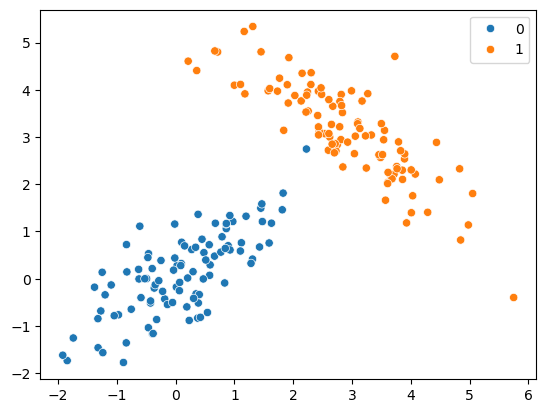

In [42]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue = y)

interactive(children=(FloatSlider(value=1.0, description='Class Prior Balance', max=2.0, min=0.1), Output()), …

              precision    recall  f1-score   support

           0       0.54      0.90      0.67       100
           1       0.70      0.23      0.35       100

    accuracy                           0.56       200
   macro avg       0.62      0.57      0.51       200
weighted avg       0.62      0.56      0.51       200

Accuracy: 0.565
Precision: 0.618
Recall: 0.565
F1 Score: 0.510


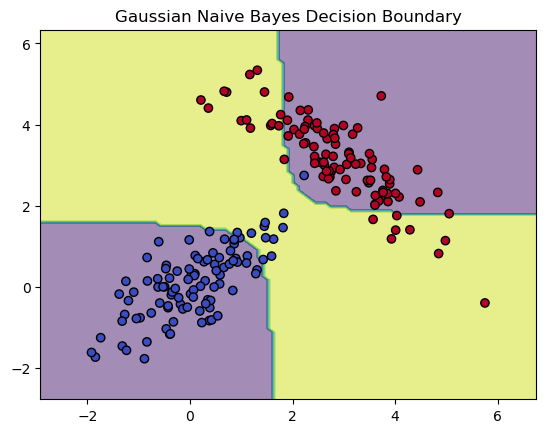

<Figure size 1200x600 with 0 Axes>

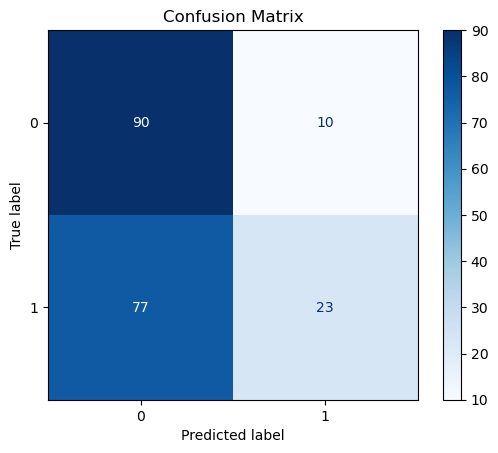

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

Accuracy: 0.995
Precision: 0.995
Recall: 0.995
F1 Score: 0.995


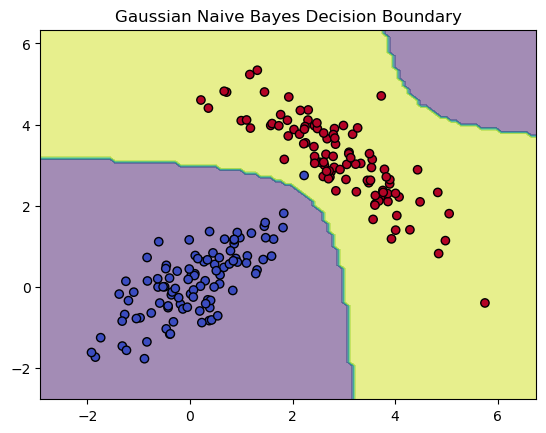

<Figure size 1200x600 with 0 Axes>

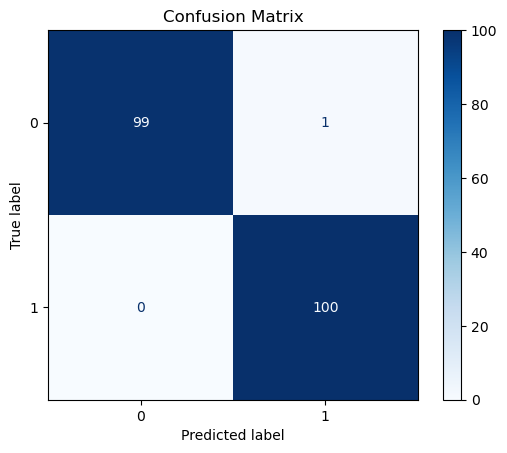

              precision    recall  f1-score   support

           0       0.58      1.00      0.74       100
           1       1.00      0.29      0.45       100

    accuracy                           0.65       200
   macro avg       0.79      0.65      0.59       200
weighted avg       0.79      0.65      0.59       200

Accuracy: 0.645
Precision: 0.792
Recall: 0.645
F1 Score: 0.594


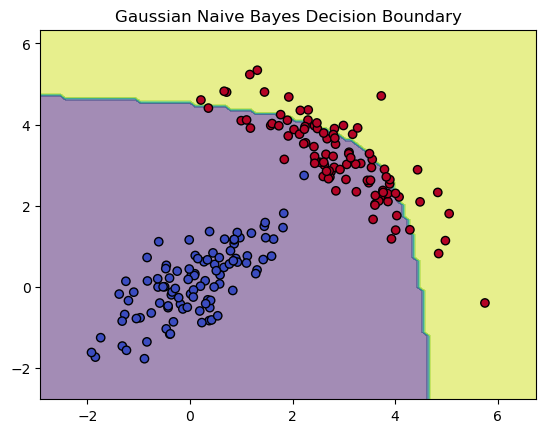

<Figure size 1200x600 with 0 Axes>

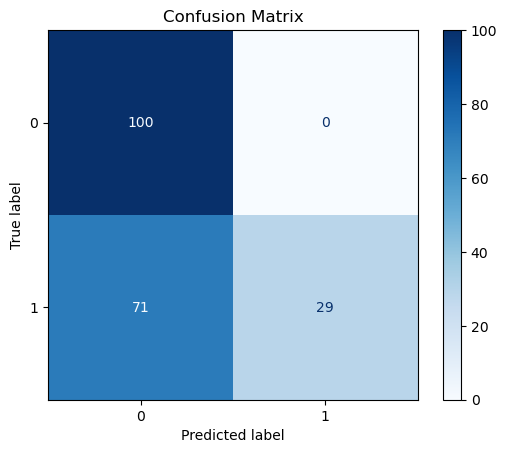

In [44]:
# Bayesian classifier function using multivariate normal distribution
def bayes_classifier(X, means, covs):
    likelihoods = [multivariate_normal(mean=mean, cov=cov).pdf(X) for mean, cov in zip(means, covs)]  # Calculate likelihood of each class
    posterior_probs = np.column_stack(likelihoods)  # Combine likelihoods to form the posterior matrix
    return np.argmax(posterior_probs, axis=1)  # Return class with highest posterior probability

# Interactive function to plot decision boundary and confusion matrix
def plot_bayes_decision_boundary(prior_balance=0.5):
    adjusted_means = [class_means[0], class_means[1] * prior_balance]  # Adjust class means based on prior balance
    
    y_pred = bayes_classifier(X, adjusted_means, class_covs)  # Classify data
    
    
    # Printing the classification report including metrics such as precision, recall, and F1-score
    print(classification_report(y, y_pred, target_names=np.unique(y).astype(str)))
    
    # Calculating additional classification metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')
    
    # Printing calculated metrics
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    
    
    
    
    cm = confusion_matrix(y, y_pred)  # Calculate confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    plot_data_and_boundaries(X, y, adjusted_means, class_covs)  # Plot data and decision boundaries
    plt.title('Gaussian Naive Bayes Decision Boundary')
    plt.show()

    plt.figure(figsize=(12, 6))
    disp.plot(cmap=plt.cm.Blues)  # Display confusion matrix
    plt.title('Confusion Matrix')
    plt.show()

# Helper function to plot data and decision boundaries
def plot_data_and_boundaries(X, y, means, covs):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = bayes_classifier(grid, means, covs)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)  # Fill contour plot with decision regions
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)  # Plot data points
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

# Set up a widget for interactive prior adjustment
interact(plot_bayes_decision_boundary, prior_balance=FloatSlider(min=0.1, max=2, step=0.1, value=1, description='Class Prior Balance'))

plot_bayes_decision_boundary(prior_balance=0.5)
plot_bayes_decision_boundary(prior_balance=1.0)
plot_bayes_decision_boundary(prior_balance=1.5)


### Gaussian Naive Bayes Classifier Decision Boundary

This script showcases an interactive Gaussian Naive Bayes classifier, demonstrating how varying the class prior balance influences the classifier's decision boundary and confusion matrix.

#### Key Components:

- **`generate_data()`**: Generates synthetic data for two classes using Gaussian distributions. This function sets up the dataset with predefined means and covariance matrices, simulating real-world scenarios where classes may have distinct or overlapping distributions.

- **`bayes_classifier()`**: Implements the Bayesian classification technique using likelihoods calculated from the multivariate normal distribution (`scipy.stats.multivariate_normal`). It computes the probability density of the data under each class's Gaussian model to determine the most likely class.
[Detailed Documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html)

- **`plot_bayes_decision_boundary()`**: An interactive function that recalculates class means based on a prior balance factor and redraws the decision boundary and confusion matrix. This function highlights how changes in assumed class priors can affect classification outcomes.

- **`plot_data_and_boundaries()`**: Helps visualize the data points and the decision boundaries calculated by the classifier. It uses a contour plot to depict areas dominated by each class based on the classifier's decisions.


## Gaussian Naive Bayes with sklearn module

In [46]:
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn import datasets
# Generate a synthetic binary classification dataset
#X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# Generate a binary classification dataset
n_samples = 1000
n_features = 2
n_classes = 2


X, y = datasets.make_blobs(n_samples= n_samples, n_features= n_features, centers= n_classes, cluster_std=[3, 6],random_state=2)
X.shape, y.shape

((1000, 2), (1000,))

<Axes: >

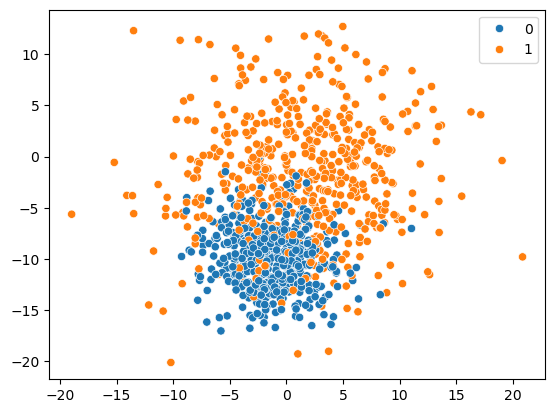

In [48]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue = y)

interactive(children=(FloatSlider(value=1.01, description='Variance Smoothing', max=5.0, min=1e-10, step=1e-05…

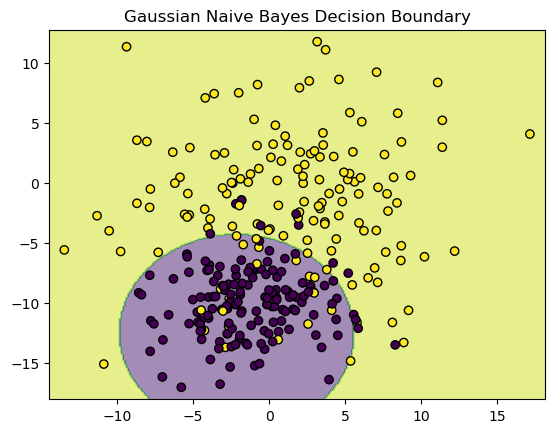

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       152
           1       0.91      0.86      0.89       148

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

Accuracy: 0.890
Precision: 0.891
Recall: 0.890
F1 Score: 0.890


<Figure size 1000x500 with 0 Axes>

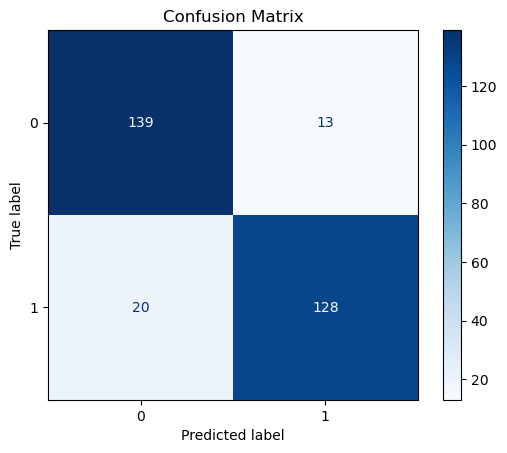

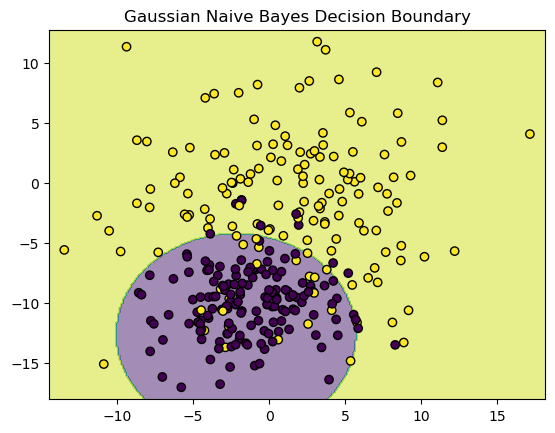

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       152
           1       0.91      0.86      0.89       148

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

Accuracy: 0.890
Precision: 0.891
Recall: 0.890
F1 Score: 0.890


<Figure size 1000x500 with 0 Axes>

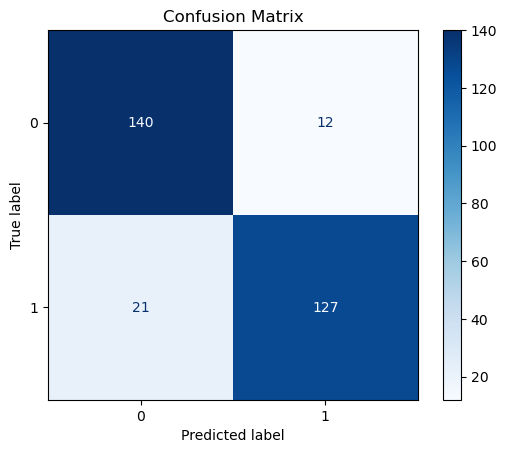

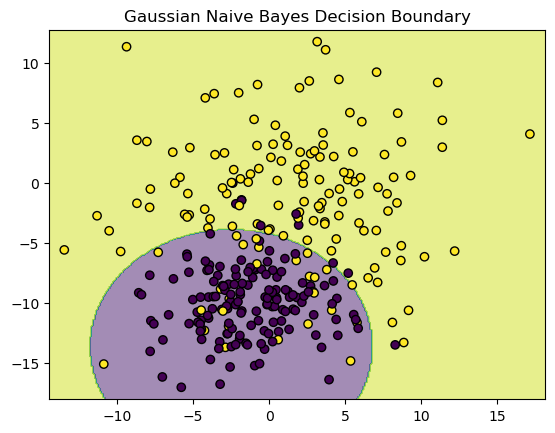

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       152
           1       0.93      0.83      0.88       148

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

Accuracy: 0.887
Precision: 0.891
Recall: 0.887
F1 Score: 0.886


<Figure size 1000x500 with 0 Axes>

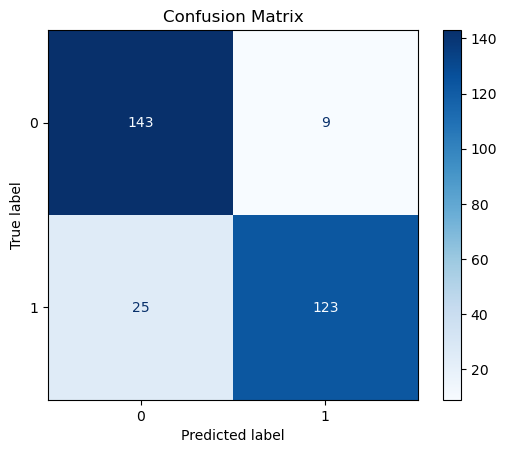

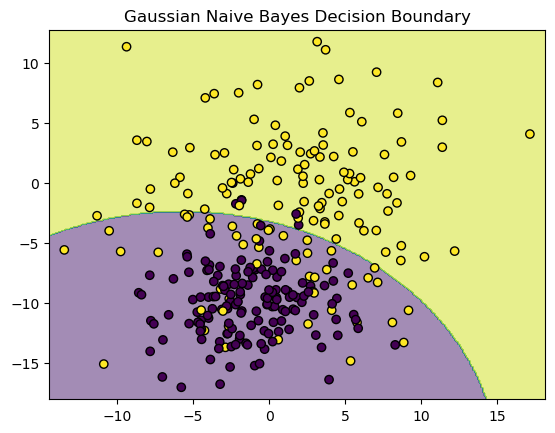

              precision    recall  f1-score   support

           0       0.76      0.97      0.85       152
           1       0.95      0.68      0.80       148

    accuracy                           0.83       300
   macro avg       0.86      0.82      0.82       300
weighted avg       0.85      0.83      0.82       300

Accuracy: 0.827
Precision: 0.854
Recall: 0.827
F1 Score: 0.823


<Figure size 1000x500 with 0 Axes>

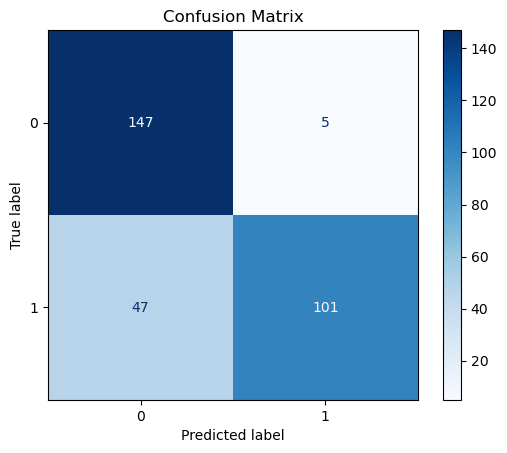

In [52]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function to train and visualize the Gaussian Naive Bayes classifier
def train_and_plot(var_smoothing=1e-9):
    # Initialize and train the Gaussian Naive Bayes classifier with a specified variance smoothing parameter
    nb = GaussianNB(var_smoothing=var_smoothing)
    nb.fit(X_train, y_train)  # Fit the model on the training data

    # Predict the labels for the testing data
    y_pred = nb.predict(X_test)

    # Visualize the decision boundary using a helper function
    plot_decision_boundary(nb, X_test, y_test)

    # Print a classification report including precision, recall, F1-score, and accuracy
    print(classification_report(y_test, y_pred, target_names=np.unique(y).astype(str)))

    # Calculate and print various classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")

    # Compute and display the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    plt.figure(figsize=(10, 5))
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

# Define a helper function to plot the decision boundary of the classifier
def plot_decision_boundary(model, X, y):
    # Set the boundaries of the plot
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    # Create a mesh grid based on the boundaries
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    # Predict the class for each point on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    # Plot the decision regions
    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Gaussian Naive Bayes Decision Boundary")
    plt.show()

# Create an interactive widget to adjust the variance smoothing parameter
interact(train_and_plot, var_smoothing=FloatSlider(min=1e-10, max=5, step=1e-5, value=1.01, description='Variance Smoothing'))

train_and_plot(var_smoothing=1e-9)
train_and_plot(var_smoothing=0.01)
train_and_plot(var_smoothing=0.1)
train_and_plot(var_smoothing=1.0)


### Interactive Visualization of Gaussian Naive Bayes Classifier with Variance Smoothing

This is designed to interactively demonstrate the effects of variance smoothing on the Gaussian Naive Bayes classifier using a synthetic dataset. we can adjust the variance smoothing parameter and observe how this affects the decision boundary, classification metrics, and the confusion matrix.

#### Key Components:

- **Model Setup and Training**:
  - `GaussianNB()`: The classifier assumes that the features follow a Gaussian distribution. The `var_smoothing` parameter adds a user-defined value to the variances of each feature, enhancing numerical stability.

- **Visualization and Metrics**:
  - `plot_decision_boundary()`: Visualizes how the decision boundary divides the feature space and how samples are classified based on their feature values.
  - `classification_report()`: Outputs detailed statistics such as precision, recall, F1-score for each class, aiding in evaluating classifier performance.